In [15]:
# Import Libraries

import tensorflow as tf
from tensorflow.keras import layers, models
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# **Understand the Dataset**

In [16]:
# Define your root directory path
data_dir = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train"

# Inspect Dataset Folder Structure & Check Image Counts
print("--- DATASET STRUCTURE & IMAGE COUNTS ---")
class_names = sorted(os.listdir(data_dir))
class_counts = {}
total_images = 0

for cls in class_names:
    cls_path = os.path.join(data_dir, cls)
    if os.path.isdir(cls_path):
        # Count all standard image formats in the folder
        extensions = ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp')
        images_in_class = []
        for ext in extensions:
            images_in_class.extend(glob.glob(os.path.join(cls_path, ext)))

        count = len(images_in_class)
        class_counts[cls] = count
        total_images += count
        print(f"Class Folder Name: '{cls}' | Total Images Found: {count}")

--- DATASET STRUCTURE & IMAGE COUNTS ---
Class Folder Name: 'bird' | Total Images Found: 1414
Class Folder Name: 'drone' | Total Images Found: 1248


In [17]:
# Identify Class Imbalance
print("\n--- CLASS IMBALANCE ANALYSIS ---")
for cls, count in class_counts.items():
    percentage = (count / total_images) * 100
    print(f"Class '{cls}': {percentage:.2f}% of the dataset")

# Print an alert if imbalance is severe (ratio worse than 1:1.5 or roughly 40%/60%)
max_class = max(class_counts, key=class_counts.get)
min_class = min(class_counts, key=class_counts.get)
imbalance_ratio = class_counts[max_class] / max_class_count if (max_class_count := class_counts[min_class]) > 0 else 0

if imbalance_ratio > 1.5:
    print(f"⚠️ Warning: Dataset is imbalanced! Ratio is 1 : {imbalance_ratio:.2f}")
else:
    print("✅ Dataset is well-balanced.")


--- CLASS IMBALANCE ANALYSIS ---
Class 'bird': 53.12% of the dataset
Class 'drone': 46.88% of the dataset
✅ Dataset is well-balanced.



--- VISUALIZING SAMPLE IMAGES ---
Found 2662 files belonging to 2 classes.


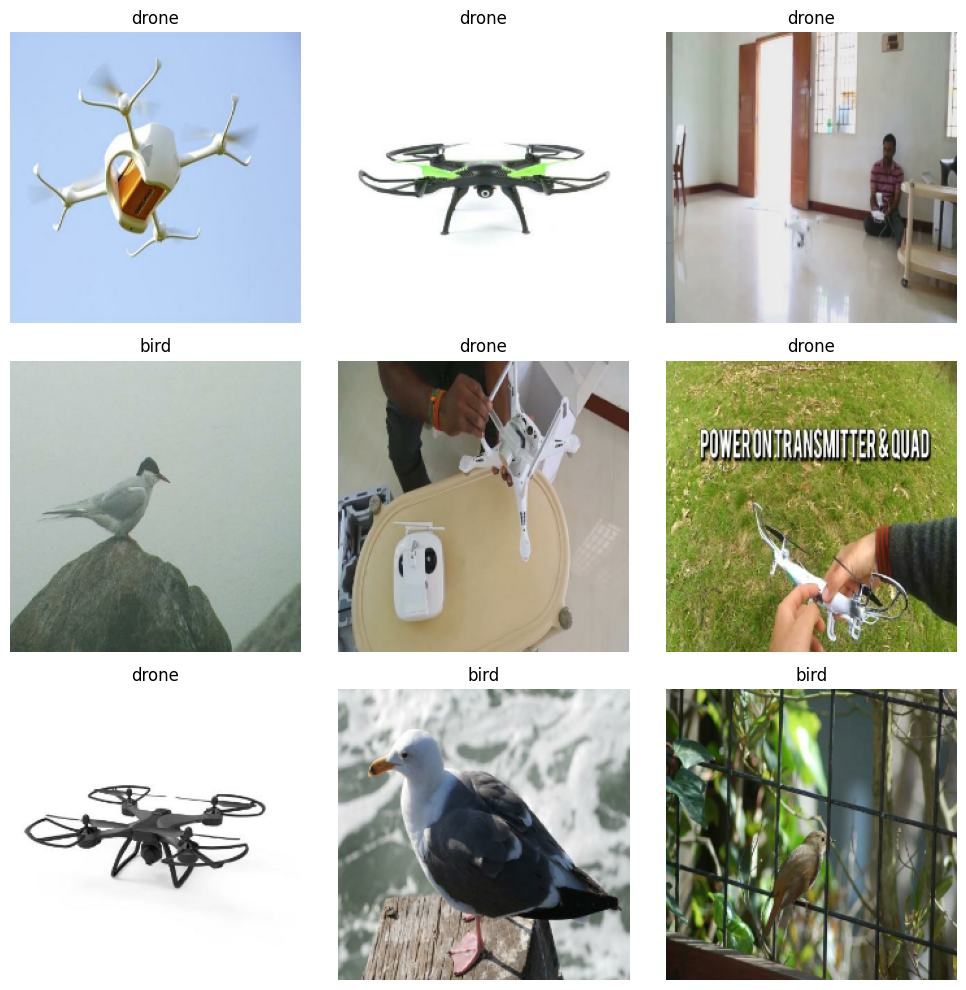

In [18]:
# Visualize Sample Images
print("\n--- VISUALIZING SAMPLE IMAGES ---")
# Load a mini-batch safely without shuffling to view clean samples
sample_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(224, 224),
    batch_size=9,
    shuffle=True # Set to True to see a mixed variety of samples
)

# Extract one batch of 9 images
for images, labels in sample_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        # Convert tensor to uint8 for clean matplotlib plotting
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(sample_ds.class_names[labels[i]])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# **Data Preprocessing**

In [19]:
train_dir = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/train"
val_dir = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/valid"
test_dir = "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/test"

train_ds = tf.keras.utils.image_dataset_from_directory(train_dir, image_size=(224, 224), batch_size=32)
val_ds = tf.keras.utils.image_dataset_from_directory(val_dir, image_size=(224, 224), batch_size=32)
test_ds = tf.keras.utils.image_dataset_from_directory(test_dir, image_size=(224, 224), batch_size=32)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.
Found 215 files belonging to 2 classes.


# **Model Building**

# *CNN Model*

In [20]:
model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')
])

# *ResNet50*

In [21]:
base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(2, activation='softmax')(x)

ResNet50_model = tf.keras.Model(inputs=base_model.input, outputs=output)

# *MobileNet*

In [22]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
output = tf.keras.layers.Dense(4, activation='softmax')(x)

MobileNet_model = tf.keras.Model(inputs=base_model.input, outputs=output)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Model Training**

In [23]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [24]:
history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 433s 5s/step - accuracy: 0.6334 - loss: 0.7016 - val_accuracy: 0.7579 - val_loss: 0.4999
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.7881 - loss: 0.4524 - val_accuracy: 0.7738 - val_loss: 0.5041
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.8302 - loss: 0.3853 - val_accuracy: 0.7964 - val_loss: 0.4491
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.8629 - loss: 0.3110 - val_accuracy: 0.7964 - val_loss: 0.5329
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.8757 - loss: 0.2722 - val_accuracy: 0.7692 - val_loss: 0.6196
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step - accuracy: 0.9050 - loss: 0.2224 - val_accuracy: 0.8145 - val_loss: 0.5421
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.9425 - loss: 0.1389 - val_accuracy: 0.8100 - val_loss: 0.6055
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.9455 - loss: 0.1425 - val_accuracy: 0.8213 - v

In [25]:
ResNet50_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [26]:
history = ResNet50_model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.9538 - loss: 0.1165 - val_accuracy: 0.9683 - val_loss: 0.0702
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 676s 8s/step - accuracy: 0.9947 - loss: 0.0163 - val_accuracy: 0.9796 - val_loss: 0.0564
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.9996 - loss: 0.0046 - val_accuracy: 0.9729 - val_loss: 0.0658
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9842 - val_loss: 0.0596
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 654s 8s/step - accuracy: 1.0000 - loss: 8.7963e-04 - val_accuracy: 0.9842 - val_loss: 0.0616
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 1.0000 - loss: 5.7286e-04 - val_accuracy: 0.9819 - val_loss: 0.0618
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 651s 8s/step - accuracy: 1.0000 - loss: 4.1901e-04 - val_accuracy: 0.9842 - val_loss: 0.0619
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 598s 7s/step - accuracy: 1.0000 - loss: 3.2791e-04 - val_accu

In [27]:
MobileNet_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [28]:
history = MobileNet_model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7682 - loss: 0.4798 - val_accuracy: 0.8258 - val_loss: 0.3475
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8727 - loss: 0.2871 - val_accuracy: 0.8439 - val_loss: 0.3370
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8967 - loss: 0.2529 - val_accuracy: 0.8643 - val_loss: 0.3247
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9181 - loss: 0.2019 - val_accuracy: 0.8733 - val_loss: 0.3357
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9136 - loss: 0.1933 - val_accuracy: 0.8869 - val_loss: 0.3156
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9459 - loss: 0.1443 - val_accuracy: 0.8959 - val_loss: 0.2909
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9448 - loss: 0.1420 - val_accuracy: 0.8688 - val_loss: 0.3564
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9572 - loss: 0.1155 - val_accuracy: 0.8756 - v

In [29]:
# Save to Colab local memory space
ResNet50_model.save("ResNet50.keras")
print("Saved successfully to local Colab runtime space!")


Saved successfully to local Colab runtime space!


# **Model Evaluation**

In [30]:
inputs = tf.keras.Input(shape=(224, 224, 3))

# FIX: Force correct ImageNet channel-centering and RGB->BGR conversion
x = tf.keras.applications.resnet50.preprocess_input(inputs)

base_model = tf.keras.applications.ResNet50(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# Pass our preprocessed data through the core network
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)

# FIX: Prevents severe training overfitting
x = tf.keras.layers.Dropout(0.5)(x)

output = tf.keras.layers.Dense(2, activation='softmax')(x)

ResNet50_model = tf.keras.Model(inputs=inputs, outputs=output)

ResNet50_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [31]:
# Train
history = ResNet50_model.fit(train_ds, validation_data=val_ds, epochs=5)

# Evaluate Test Set Again
test_loss, test_accuracy = ResNet50_model.evaluate(test_ds)
print(f"\nCorrected Test Accuracy: {test_accuracy * 100:.2f}%")


Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 669s 8s/step - accuracy: 0.9339 - loss: 0.1708 - val_accuracy: 0.9887 - val_loss: 0.0454
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 657s 8s/step - accuracy: 0.9880 - loss: 0.0365 - val_accuracy: 0.9796 - val_loss: 0.0454
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 599s 7s/step - accuracy: 0.9910 - loss: 0.0259 - val_accuracy: 0.9751 - val_loss: 0.0503
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 680s 8s/step - accuracy: 0.9906 - loss: 0.0249 - val_accuracy: 0.9910 - val_loss: 0.0488
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 657s 8s/step - accuracy: 0.9970 - loss: 0.0101 - val_accuracy: 0.9910 - val_loss: 0.0566
7/7 ━━━━━━━━━━━━━━━━━━━━ 42s 6s/step - accuracy: 0.9860 - loss: 0.0478

Corrected Test Accuracy: 98.60%


In [43]:
# Re-load the test dataset WITHOUT shuffling
test_ds_unshuffled = tf.keras.utils.image_dataset_from_directory(
    "/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/classification_dataset/test",
    image_size=(224, 224),
    batch_size=32,
    shuffle=False  # CRITICAL: Keeps everything in strict, static order
)

# Extract true labels safely from the static dataset
y_true = np.concatenate([y for x, y in test_ds_unshuffled], axis=0)

# Predict on the static dataset
predictions = ResNet50_model.predict(test_ds_unshuffled)
y_pred = np.argmax(predictions, axis=1)

# Print the corrected metrics
print("--- CORRECTED CLASSIFICATION REPORT ---")
print(classification_report(y_true, y_pred, target_names=test_ds_unshuffled.class_names))


Found 215 files belonging to 2 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 43s 6s/step
--- CORRECTED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

        bird       0.98      1.00      0.99       121
       drone       1.00      0.97      0.98        94

    accuracy                           0.99       215
   macro avg       0.99      0.98      0.99       215
weighted avg       0.99      0.99      0.99       215



7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 6s/step


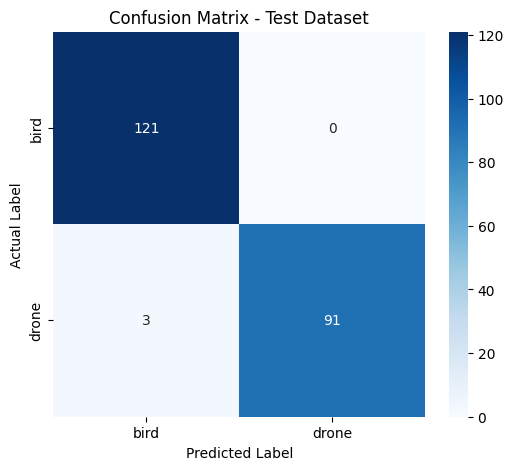

In [44]:
# Get true labels and predictions
# Note: Ensure test_ds is NOT shuffled so predictions match true labels perfectly
y_true = np.concatenate([y for x, y in test_ds_unshuffled], axis=0)
predictions = ResNet50_model.predict(test_ds_unshuffled)
y_pred = np.argmax(predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the matrix using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=test_ds_unshuffled.class_names,
    yticklabels=test_ds_unshuffled.class_names
)

plt.title('Confusion Matrix - Test Dataset')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

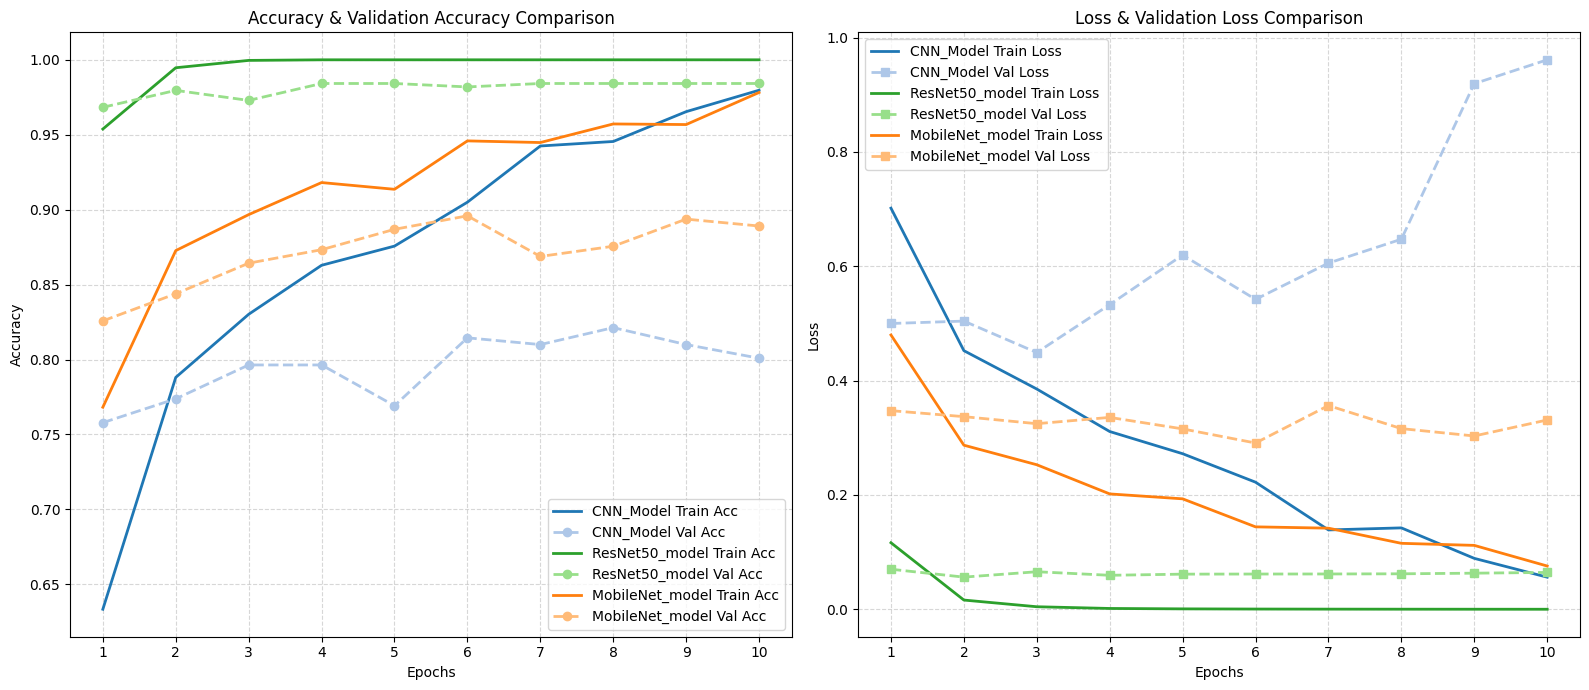

In [45]:
import re
import matplotlib.pyplot as plt

# Paste your complete logs here
log_data = """
Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 433s 5s/step - accuracy: 0.6334 - loss: 0.7016 - val_accuracy: 0.7579 - val_loss: 0.4999
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 350s 4s/step - accuracy: 0.7881 - loss: 0.4524 - val_accuracy: 0.7738 - val_loss: 0.5041
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 337s 4s/step - accuracy: 0.8302 - loss: 0.3853 - val_accuracy: 0.7964 - val_loss: 0.4491
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.8629 - loss: 0.3110 - val_accuracy: 0.7964 - val_loss: 0.5329
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.8757 - loss: 0.2722 - val_accuracy: 0.7692 - val_loss: 0.6196
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step - accuracy: 0.9050 - loss: 0.2224 - val_accuracy: 0.8145 - val_loss: 0.5421
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 341s 4s/step - accuracy: 0.9425 - loss: 0.1389 - val_accuracy: 0.8100 - val_loss: 0.6055
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 335s 4s/step - accuracy: 0.9455 - loss: 0.1425 - val_accuracy: 0.8213 - val_loss: 0.6473
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 391s 4s/step - accuracy: 0.9654 - loss: 0.0892 - val_accuracy: 0.8100 - val_loss: 0.9193
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 384s 4s/step - accuracy: 0.9797 - loss: 0.0563 - val_accuracy: 0.8009 - val_loss: 0.9610


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.9538 - loss: 0.1165 - val_accuracy: 0.9683 - val_loss: 0.0702
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 676s 8s/step - accuracy: 0.9947 - loss: 0.0163 - val_accuracy: 0.9796 - val_loss: 0.0564
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 597s 7s/step - accuracy: 0.9996 - loss: 0.0046 - val_accuracy: 0.9729 - val_loss: 0.0658
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9842 - val_loss: 0.0596
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 654s 8s/step - accuracy: 1.0000 - loss: 8.7963e-04 - val_accuracy: 0.9842 - val_loss: 0.0616
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 653s 8s/step - accuracy: 1.0000 - loss: 5.7286e-04 - val_accuracy: 0.9819 - val_loss: 0.0618
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 651s 8s/step - accuracy: 1.0000 - loss: 4.1901e-04 - val_accuracy: 0.9842 - val_loss: 0.0619
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 598s 7s/step - accuracy: 1.0000 - loss: 3.2791e-04 - val_accuracy: 0.9842 - val_loss: 0.0622
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 675s 8s/step - accuracy: 1.0000 - loss: 2.6849e-04 - val_accuracy: 0.9842 - val_loss: 0.0633
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 652s 8s/step - accuracy: 1.0000 - loss: 2.1705e-04 - val_accuracy: 0.9842 - val_loss: 0.0646


Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7682 - loss: 0.4798 - val_accuracy: 0.8258 - val_loss: 0.3475
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 199s 2s/step - accuracy: 0.8727 - loss: 0.2871 - val_accuracy: 0.8439 - val_loss: 0.3370
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8967 - loss: 0.2529 - val_accuracy: 0.8643 - val_loss: 0.3247
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9181 - loss: 0.2019 - val_accuracy: 0.8733 - val_loss: 0.3357
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.9136 - loss: 0.1933 - val_accuracy: 0.8869 - val_loss: 0.3156
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.9459 - loss: 0.1443 - val_accuracy: 0.8959 - val_loss: 0.2909
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9448 - loss: 0.1420 - val_accuracy: 0.8688 - val_loss: 0.3564
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 145s 2s/step - accuracy: 0.9572 - loss: 0.1155 - val_accuracy: 0.8756 - val_loss: 0.3161
Epoch 9/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.9568 - loss: 0.1119 - val_accuracy: 0.8937 - val_loss: 0.3032
Epoch 10/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.9782 - loss: 0.0758 - val_accuracy: 0.8891 - val_loss: 0.3312
"""

# Split the log into separate blocks based on repeated "Epoch 1/10" headers
run_texts = re.split(r'(?=Epoch 1/10)', log_data.strip())
run_texts = [r for r in run_texts if r.strip()]

model_names = ["CNN_Model", "ResNet50_model", "MobileNet_model"]
data = {}

epoch_num_pattern = r"Epoch (\d+)/10"
metrics_pattern = r"accuracy:\s*([\d.]+)\s*-\s*loss:\s*([\d.e-]+)\s*-\s*val_accuracy:\s*([\d.]+)\s*-\s*val_loss:\s*([\d.e-]+)"

for idx, text in enumerate(run_texts):
    if idx >= len(model_names):
        break
    name = model_names[idx]
    data[name] = {"epochs": [], "loss": [], "train_acc": [], "val_acc": [], "val_loss": []}

    lines = text.strip().split('\n')
    current_epoch = None

    for line in lines:
        epoch_match = re.search(epoch_num_pattern, line)
        if epoch_match:
            current_epoch = int(epoch_match.group(1))
            continue

        metrics_match = re.search(metrics_pattern, line)
        if metrics_match and current_epoch is not None:
            data[name]["epochs"].append(current_epoch)
            data[name]["train_acc"].append(float(metrics_match.group(1)))
            data[name]["loss"].append(float(metrics_match.group(2)))
            data[name]["val_acc"].append(float(metrics_match.group(3)))
            data[name]["val_loss"].append(float(metrics_match.group(4)))
            current_epoch = None

# Color themes per model to map variations clearly
colors = {
    "CNN_Model": {"train": "#1f77b4", "val": "#aec7e8"},       # Blue shades
    "ResNet50_model": {"train": "#2ca02c", "val": "#98df8a"},  # Green shades
    "MobileNet_model": {"train": "#ff7f0e", "val": "#ffbb78"} # Orange shades
}

plt.figure(figsize=(16, 7))

# Plot 1: Accuracy & Validation Accuracy (Together)
plt.subplot(1, 2, 1)
for model_name, metrics in data.items():
    if metrics["epochs"]:
        # Solid Line for Training Accuracy
        plt.plot(metrics["epochs"], metrics["train_acc"], linestyle="-",
                 color=colors[model_name]["train"], label=f"{model_name} Train Acc", linewidth=2)
        # Dashed Line + Marker for Validation Accuracy
        plt.plot(metrics["epochs"], metrics["val_acc"], linestyle="--", marker="o",
                 color=colors[model_name]["val"], label=f"{model_name} Val Acc", linewidth=2)
plt.title("Accuracy & Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

# Plot 2: Loss & Validation Loss (Together)
plt.subplot(1, 2, 2)
for model_name, metrics in data.items():
    if metrics["epochs"]:
        # Solid Line for Training Loss
        plt.plot(metrics["epochs"], metrics["loss"], linestyle="-",
                 color=colors[model_name]["train"], label=f"{model_name} Train Loss", linewidth=2)
        # Dashed Line + Marker for Validation Loss
        plt.plot(metrics["epochs"], metrics["val_loss"], linestyle="--", marker="s",
                 color=colors[model_name]["val"], label=f"{model_name} Val Loss", linewidth=2)
plt.title("Loss & Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(range(1, 11))
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()


# **Streamlit**

In [35]:
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

--2026-05-25 13:22:27--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.113.3
Connecting to github.com (github.com)|140.82.113.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.1/cloudflared-linux-amd64 [following]
--2026-05-25 13:22:27--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.1/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/dccf1d7f-b87c-44ed-93e1-f3f5a431f244?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-05-25T14%3A12%3A45Z&rscd=attachment%3B+filename%3Dcloudflared-linux-amd64&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2026-05-25T1

In [36]:
%%writefile tenfw.py

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

# -------------------------------
# PAGE CONFIGURATION
# -------------------------------

st.set_page_config(
    page_title="Aerial Object Classifier",
    page_icon="🦅",
    layout="wide"
)

# -------------------------------
# LOAD MODEL
# -------------------------------
# FIX: Correctly load the model object instead of using a string path
@st.cache_resource  # Caches the model so it doesn't reload on every button click
def load_my_model():
    return tf.keras.models.load_model('/content/drive/MyDrive/datascience/Mini Projects/Aerial Object Classification & Detection/ResNet50.keras')

model = load_my_model()
classes = ["bird", "drone"]

# -------------------------------
# UI
# -------------------------------
st.title("🦅 Bird vs 🛰️ Drone Classification (ResNet50 - TensorFlow)")
st.write("Upload an image to see if it's a bird or a drone.")


file = st.file_uploader("Upload Image", type=["jpg", "jpeg", "png", "webp"])

# -------------------------------
# PREDICTION
# -------------------------------
if file:
    # Display the uploaded image to the user
    st.image(file, caption="Uploaded Image", use_container_width=True)

    # FIX: Convert to RGB (handles 4-channel PNGs) and resize
    img = Image.open(file).convert('RGB').resize((224, 224))

    # FIX: Convert to numpy array WITHOUT dividing by 255.0
    img = np.array(img, dtype=np.float32)
    img = np.expand_dims(img, axis=0)

    # Run prediction
    pred = model.predict(img)
    class_idx = np.argmax(pred)
    confidence = np.max(pred) * 100

    # Output results cleanly
    st.subheader(f"Prediction: {classes[class_idx]}")
    st.write(f"Confidence: {confidence:.2f}%")


Overwriting tenfw.py


In [37]:
!streamlit run /content/tenfw.py &>/content/logs.txt &

In [38]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://teaching-maintained-tvs-starter.trycloudflare.com
